In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
import os, getpass

os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Paste your Kaggle token here: ")

Paste your Kaggle token here: ··········


In [4]:
!pip install -q kaggle

In [5]:
!kaggle datasets download -d mloey1/ahdd1

Dataset URL: https://www.kaggle.com/datasets/mloey1/ahdd1
License(s): DbCL-1.0
100% 50.6M/50.6M [00:00<00:00, 106MB/s]



In [6]:
!unzip -q ahdd1.zip -d ahdd1

In [7]:
!find ahdd1 -maxdepth 3 -type f

ahdd1/csvTrainImages 60k x 784/csvTrainImages 60k x 784.csv
ahdd1/Arabic Handwritten Digits Dataset CSV/csvTrainLabel 60k x 1.csv
ahdd1/Arabic Handwritten Digits Dataset CSV/csvTestLabel 10k x 1.csv
ahdd1/Arabic Handwritten Digits Dataset CSV/csvTrainImages 60k x 784.csv
ahdd1/Arabic Handwritten Digits Dataset CSV/csvTestImages 10k x 784.csv
ahdd1/csvTrainLabel 60k x 1.csv
ahdd1/csvTestLabel 10k x 1.csv
ahdd1/csvTrainImages 60k x 784.csv
ahdd1/csvTestImages 10k x 784.csv
ahdd1/Train + Test Matlab.mat


In [8]:
import numpy as np
import matplotlib.pyplot as plt

train_images = np.loadtxt(
    "ahdd1/csvTrainImages 60k x 784.csv",
    delimiter=","
)

train_labels = np.loadtxt(
    "ahdd1/csvTrainLabel 60k x 1.csv",
    delimiter=","
)

test_images = np.loadtxt(
    "ahdd1/csvTestImages 10k x 784.csv",
    delimiter=","
)

test_labels = np.loadtxt(
    "ahdd1/csvTestLabel 10k x 1.csv",
    delimiter=","
)

print("Train images:", train_images.shape)
print("Train labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

print("Unique labels:", np.unique(train_labels))

Train images: (60000, 784)
Train labels: (60000,)
Test images: (10000, 784)
Test labels: (10000,)
Unique labels: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


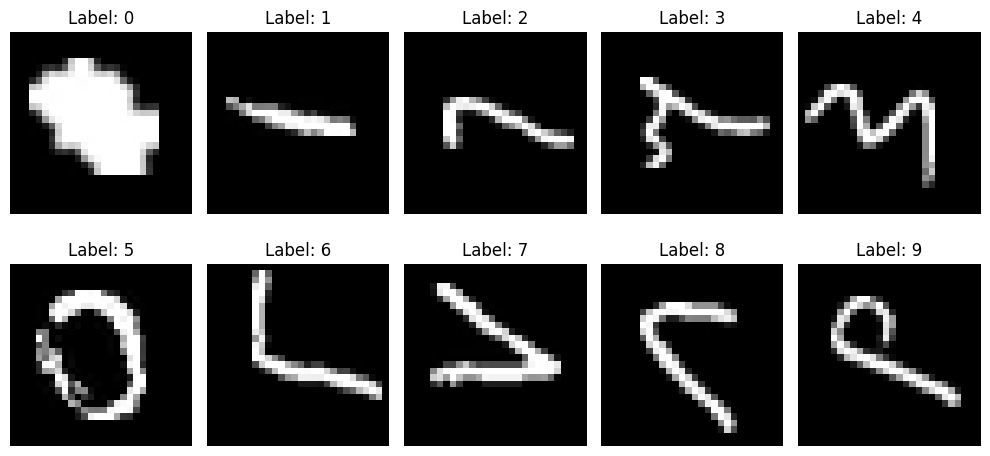

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image = train_images[i].reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {int(train_labels[i])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

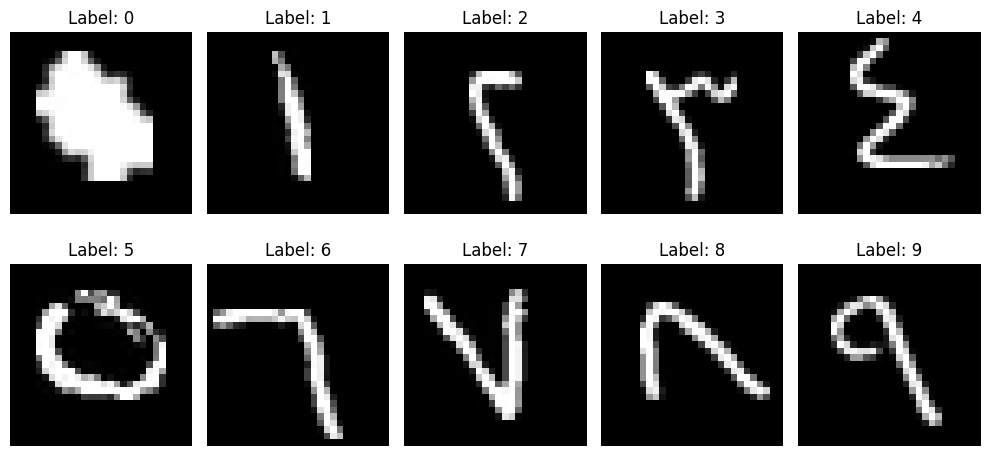

In [10]:
# Reshape flat 784-pixel rows into 28x28 images
train_images = train_images.reshape(-1, 28, 28)
test_images = test_images.reshape(-1, 28, 28)

# Fix orientation
train_images = np.transpose(train_images, (0, 2, 1))
test_images = np.transpose(test_images, (0, 2, 1))

# Show one sample from each class
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for digit in range(10):
    idx = np.where(train_labels == digit)[0][0]
    ax = axes.flat[digit]

    ax.imshow(train_images[idx], cmap="gray")
    ax.set_title(f"Label: {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Convert labels to integers
train_labels = train_labels.astype(np.int32)
test_labels = test_labels.astype(np.int32)

# Scale pixels from 0-255 to 0-1
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Pad 28x28 -> 32x32
train_images = np.pad(
    train_images,
    ((0, 0), (2, 2), (2, 2)),
    mode="constant"
)

test_images = np.pad(
    test_images,
    ((0, 0), (2, 2), (2, 2)),
    mode="constant"
)

# Add channel dimension: (N, 32, 32) -> (N, 32, 32, 1)
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

print("Train images:", train_images.shape)
print("Test images:", test_images.shape)
print("Train labels:", train_labels.shape)
print("Test labels:", test_labels.shape)

Train images: (60000, 32, 32, 1)
Test images: (10000, 32, 32, 1)
Train labels: (60000,)
Test labels: (10000,)


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class TrainableSubsampling(tf.keras.layers.Layer):
    def build(self, input_shape):
        channels = input_shape[-1]

        self.alpha = self.add_weight(
            name="alpha",
            shape=(channels,),
            initializer="ones",
            trainable=True
        )

        self.beta = self.add_weight(
            name="beta",
            shape=(channels,),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):
        x = tf.nn.avg_pool2d(
            inputs,
            ksize=2,
            strides=2,
            padding="VALID"
        )

        x = x * 4.0
        x = x * self.alpha + self.beta

        return tf.nn.sigmoid(x)


model = keras.Sequential([
    keras.Input(shape=(32, 32, 1)),

    layers.Conv2D(
        6,
        kernel_size=5,
        activation="tanh",
        padding="valid"
    ),

    TrainableSubsampling(),

    layers.Conv2D(
        16,
        kernel_size=5,
        activation="tanh",
        padding="valid"
    ),

    TrainableSubsampling(),

    layers.Conv2D(
        120,
        kernel_size=5,
        activation="tanh",
        padding="valid"
    ),

    layers.Flatten(),

    layers.Dense(
        84,
        activation="tanh"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ trainable_subsampling           │ (None, 14, 14, 6)      │            12 │
│ (TrainableSubsampling)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ trainable_subsampling_1         │ (None, 5, 5, 16)       │            32 │
│ (TrainableSubsampling)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,750 (241.21 KB)

 Trainable params: 61,750 (241.21 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.8928 - loss: 0.3632 - val_accuracy: 0.9648 - val_loss: 0.1174
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9756 - loss: 0.0856 - val_accuracy: 0.9780 - val_loss: 0.0715
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9819 - loss: 0.0617 - val_accuracy: 0.9842 - val_loss: 0.0521
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9860 - loss: 0.0469 - val_accuracy: 0.9873 - val_loss: 0.0377
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9880 - loss: 0.0395 - val_accuracy: 0.9885 - val_loss: 0.0381
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9894 - loss: 0.0338 - val_accuracy: 0.9877 - val_loss: 0.0398
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9910 - loss: 0.0291 - val_accuracy: 0.9885 - val_loss: 0.0357
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9916 - loss: 0.0267 - 

In [15]:
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.9857000112533569


In [16]:
model.save("arabic_lenet5.keras")

In [17]:
from google.colab import files
files.download("arabic_lenet5.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>